In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import time
import tqdm
import seaborn as sns

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='data/', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.FashionMNIST(
    root='data/', train=False, download=True, transform=transform)

train_indices, val_indices = train_test_split(
    range(len(train_dataset)),
    test_size=0.1,
    stratify=train_dataset.targets,
    random_state=42
)

train_split = Subset(train_dataset, train_indices)
val_split = Subset(train_dataset, val_indices)

train_batch_size = 512 #Define train batch size
test_batch_size  = 256 #Define test batch size (can be larger than train batch size)


# Define dataloader objects that help to iterate over batches and samples for
# training, validation and testing
train_batches = DataLoader(train_split, batch_size=train_batch_size, shuffle=True)
val_batches = DataLoader(val_split, batch_size=train_batch_size, shuffle=True)
test_batches = DataLoader(test_dataset, batch_size=test_batch_size, shuffle=True)
                                           
num_train_batches=len(train_batches)
num_val_batches=len(val_batches)
num_test_batches=len(test_batches)

In [28]:
import torch.nn as nn

class FCN(nn.Module):
    def __init__(self, config='100K'):
        super().__init__()
        self.config = config
        layers = []
        
        if config == '100K':
            # Structure: 784 → [Linear → BN → ReLU → Dropout] → 10
            layers.extend([
                nn.Flatten(),
                nn.Linear(28*28, 124),
                nn.BatchNorm1d(124),  # Added BatchNorm
                nn.ReLU(),
                nn.Dropout(0.5),
                nn.Linear(124, 10)
            ])
        elif config == '50K':
            # Structure: 784 → [Linear → BN → ReLU → Dropout] → 10
            layers.extend([
                nn.Flatten(),
                nn.Linear(28*28, 62),
                nn.BatchNorm1d(62),  # Added BatchNorm
                nn.ReLU(),
                nn.Dropout(0.5),
                nn.Linear(62, 10)
            ])
        elif config == '200K':
            # Structure: 784 → [Linear → BN → ReLU → Dropout] → 100 → [Linear → BN → ReLU → Dropout] → 10
            layers.extend([
                nn.Flatten(),
                nn.Linear(28*28, 200),
                nn.BatchNorm1d(200),  # Added BatchNorm
                nn.ReLU(),
                nn.Dropout(0.5),
                nn.Linear(200, 100),
                nn.BatchNorm1d(100),  # Added BatchNorm
                nn.ReLU(),
                nn.Dropout(0.5),
                nn.Linear(100, 10)
            ])
            
        self.net = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.net(x)

In [29]:
# Initialize neural network model with input, output and hidden layer dimensions
model = FCN(config = '100K')
    
# Define the learning rate and epochs number
learning_rate = 0.01
epochs = 30


train_loss_list = np.zeros((epochs,))
validation_accuracy_list = np.zeros((epochs,))

# Define loss function  and optimizer
loss_func = nn.CrossEntropyLoss()# Use Cross Entropy loss from torch.nn 
optimizer = optim.Adam(model.parameters(), lr=0.01)# Use optimizers from torch.optim


start_time = time.perf_counter()

# Iterate over epochs, batches with progress bar and train+ validate the ACAIGFCN
# Track the loss and validation accuracy
for epoch in tqdm.trange(epochs):
    model.train()
    train_loss = 0.0
    # ACAIGFCN Training 
    for train_features, train_labels in train_batches:
        # Set model into training mode
        
        
        # Reshape images into a vector
        train_features = train_features.reshape(-1, 28*28)
        optimizer.zero_grad()
        outputs = model(train_features)
        loss = loss_func(outputs, train_labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        # Reset gradients, Calculate training loss on model 
        # Perfrom optimization, back propagation
 
    # Record loss for the epoch
    train_loss_list[epoch] = train_loss / len(train_batches)
    
    
    model.eval()
    val_acc = 0.0
    with torch.no_grad():      
    # ACAIGFCN Validation
    
        # Telling PyTorch we aren't passing inputs to network for training purpose
        for val_features, val_labels in val_batches:
        
             # Reshape validation images into a vector
            val_features = val_features.reshape(-1, 28*28)
          
            outputs = model(val_features)
            preds = torch.argmax(outputs, dim=1)
            val_acc += (preds == val_labels).sum().item() / len(val_labels)
            validation_accuracy_list[epoch] = val_acc / len(val_batches)
            # Compute validation outputs (targets) 
            # and compute accuracy 
            
    # Record accuracy for the epoch; print training loss, validation accuracy
    print("Epoch: "+ str(epoch) +"; Validation Accuracy:" + str(val_acc/len(val_batches)*100) + '%')

end_time = time.perf_counter()
elapsed_time = end_time - start_time

  3%|██▊                                                                                | 1/30 [00:07<03:37,  7.52s/it]

Epoch: 0; Validation Accuracy:84.84771286231884%


  7%|█████▌                                                                             | 2/30 [00:15<03:33,  7.62s/it]

Epoch: 1; Validation Accuracy:87.0322407155797%


 10%|████████▎                                                                          | 3/30 [00:23<03:32,  7.87s/it]

...

Epoch: 27; Validation Accuracy:89.8642719655797%


 97%|███████████████████████████████████████████████████████████████████████████████▎  | 29/30 [03:49<00:08,  8.11s/it]

Epoch: 28; Validation Accuracy:89.95626698369566%


100%|██████████████████████████████████████████████████████████████████████████████████| 30/30 [03:57<00:00,  7.90s/it]

Epoch: 29; Validation Accuracy:89.36112998188405%


training time: 237.011371 s


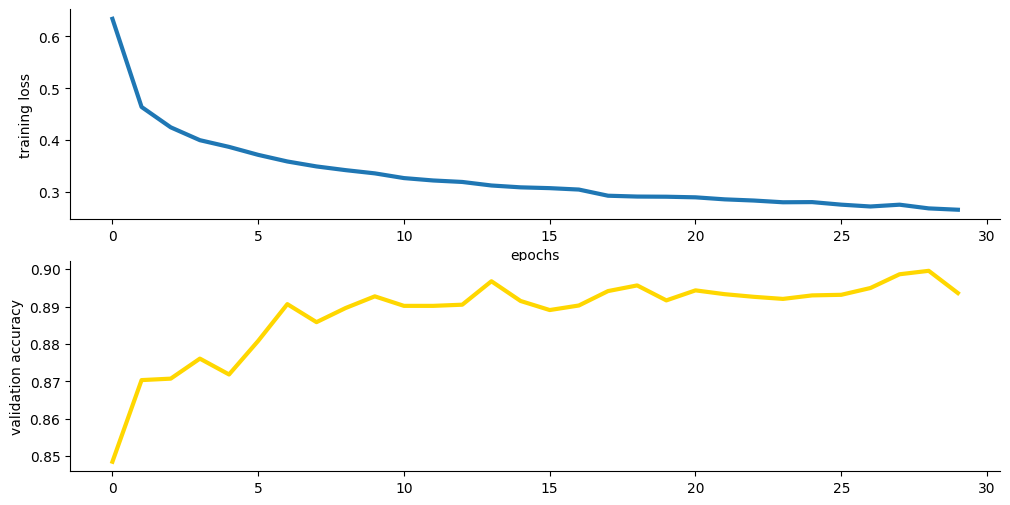

In [30]:
# Plot training loss and validation accuracy throughout the training epochs
# Plot training loss and validation accuracy throughout the training epochs
print(f"training time: {elapsed_time:.6f} s")

plt.figure(figsize = (12, 6))

plt.subplot(2, 1, 1)
plt.plot(train_loss_list, linewidth = 3)
plt.ylabel("training loss")
plt.xlabel("epochs")

plt.subplot(2, 1, 2)
plt.plot(validation_accuracy_list, linewidth = 3, color = 'gold')
plt.ylabel("validation accuracy")
sns.despine()

In [31]:
model.eval()
test_correct = 0
test_total = len(test_dataset)
with torch.no_grad():
    
    for test_features, test_labels in test_batches:

        
        # Reshape test images into a vector
        test_features = test_features.reshape(-1, 28*28)
        outputs = model(test_features)
        preds = torch.argmax(outputs, dim=1)
        test_correct += (preds == test_labels).sum().item()
         # Compute validation outputs (targets) 
         # and compute accuracy 
    
    # Compute total (mean) accuracy
    # Report total (mean) accuracy, can also compute std based on batches
test_accuracy = test_correct / test_total
print(f"Test Accuracy: {test_accuracy:.2%}")

Test Accuracy: 88.20%


In [32]:
def train_fcn(model, train_loader, val_loader, num_epochs=30):
    model.to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.CrossEntropyLoss()
    
    train_losses = []
    val_accuracies = []
    
    for epoch in range(num_epochs):

        model.train()
        epoch_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        val_acc = 100 * correct / total
        train_losses.append(epoch_loss/len(train_loader))
        val_accuracies.append(val_acc)
        
        print(f'FCN Epoch [{epoch+1}/{num_epochs}] Loss: {train_losses[-1]:.4f} Val Acc: {val_acc:.2f}%')
    
    return train_losses, val_accuracies


def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total


def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

In [33]:
configs_FCN = ['100K', '50K', '200K']
results_FCN = {}
for config in configs_FCN:
    start_time = time.perf_counter()
    print(f'\nTraining {config} model...')
    model = FCN(config=config)
    model.config = config
    
    params = count_parameters(model)
    print(f'{config} model parameters: {params/1e3:.1f}K')
    

    train_loss, val_acc = train_fcn(model, train_batches, val_batches)
    

    results_FCN[config] = {
        'params': params,
        'train_loss': train_loss,
        'val_acc': val_acc,
        'test_acc': evaluate_model(model, test_batches)
    }
    end_time = time.perf_counter()
    elapsed_time = end_time - start_time
    print(f"training time: {elapsed_time:.6f} s")
    



Training 100K model...
100K model parameters: 98.8K
FCN Epoch [1/30] Loss: 0.6308 Val Acc: 83.95%
FCN Epoch [2/30] Loss: 0.4674 Val Acc: 86.22%
FCN Epoch [3/30] Loss: 0.4246 Val Acc: 87.13%
FCN Epoch [4/30] Loss: 0.4030 Val Acc: 87.80%
FCN Epoch [5/30] Loss: 0.3866 Val Acc: 87.93%
FCN Epoch [6/30] Loss: 0.3766 Val Acc: 88.52%
FCN Epoch [7/30] Loss: 0.3631 Val Acc: 89.02%
FCN Epoch [8/30] Loss: 0.3551 Val Acc: 89.23%
FCN Epoch [9/30] Loss: 0.3453 Val Acc: 88.70%
FCN Epoch [10/30] Loss: 0.3426 Val Acc: 89.30%
FCN Epoch [11/30] Loss: 0.3350 Val Acc: 88.50%
FCN Epoch [12/30] Loss: 0.3249 Val Acc: 88.92%
FCN Epoch [13/30] Loss: 0.3249 Val Acc: 89.32%
FCN Epoch [14/30] Loss: 0.3190 Val Acc: 89.17%
FCN Epoch [15/30] Loss: 0.3141 Val Acc: 89.22%
FCN Epoch [16/30] Loss: 0.3084 Val Acc: 89.28%
FCN Epoch [17/30] Loss: 0.3019 Val Acc: 89.60%
FCN Epoch [18/30] Loss: 0.3014 Val Acc: 88.80%
FCN Epoch [19/30] Loss: 0.2960 Val Acc: 89.22%
FCN Epoch [20/30] Loss: 0.2933 Val Acc: 89.43%
FCN Epoch [21/30

In [34]:
for config in configs_FCN:
    print(results_FCN[config]['test_acc'])

88.08
87.04
88.35


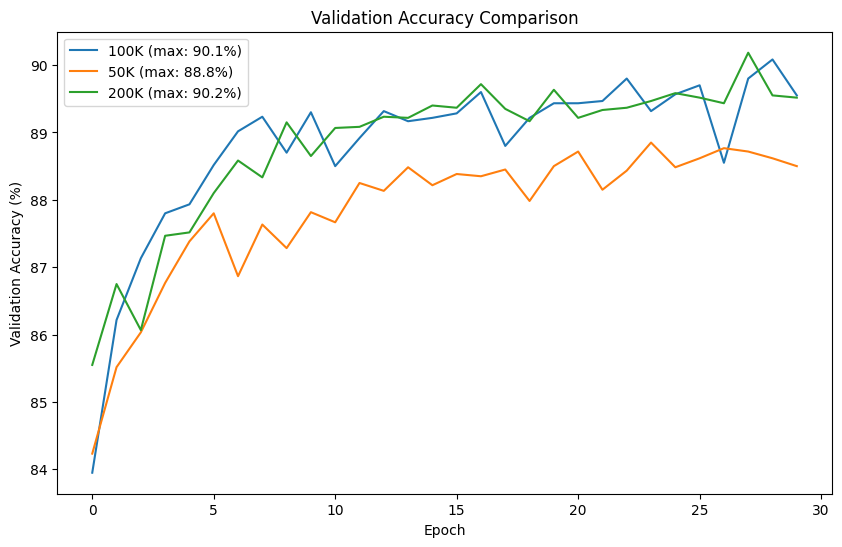

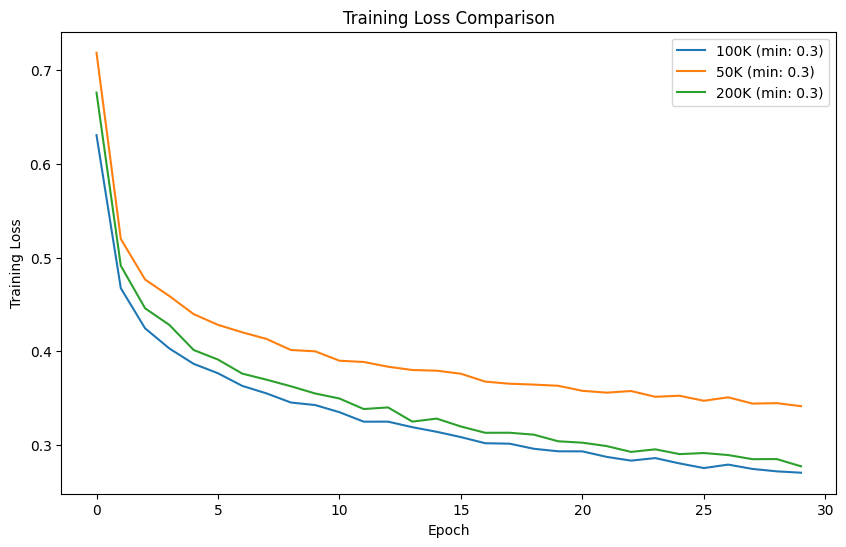

In [40]:
plt.figure(figsize=(10, 6))
for config in configs_FCN:
    plt.plot(results_FCN[config]['val_acc'], 
            label=f'{config} (max: {max(results_FCN[config]["val_acc"]):.1f}%)')
    plt.xlabel('Epoch')
    plt.ylabel('Validation Accuracy (%)')
    plt.title('Validation Accuracy Comparison')
    plt.legend()
    
plt.figure(figsize=(10, 6))
for config in configs_FCN:
    plt.plot(results_FCN[config]['train_loss'], 
            label=f'{config} (min: {min(results_FCN[config]["train_loss"]):.1f})')
    plt.xlabel('Epoch')
    plt.ylabel('Training Loss')
    plt.title('Training Loss Comparison')
    plt.legend()

In [41]:
class CNN(nn.Module):
    def __init__(self, config='100K'):
        super().__init__()
        
        # Build convolutional layers dynamically for each config
        if config == '100K':
            self.conv_layers = nn.Sequential(
                nn.Conv2d(1, 32, 3, padding=1),  # 28x28
                nn.BatchNorm2d(32),  # Added BatchNorm
                nn.ReLU(),
                nn.MaxPool2d(2),  # 14x14
                nn.Conv2d(32, 48, 3, padding=1),
                nn.BatchNorm2d(48),  # Added BatchNorm
                nn.ReLU(),
                nn.MaxPool2d(2)  # 7x7
            )
            self.fc = nn.Sequential(
                nn.Linear(48*7*7, 35),
                nn.BatchNorm1d(35),  # Added BatchNorm
                nn.ReLU(),
                nn.Dropout(0.5),  # Added Dropout
                nn.Linear(35, 10)
            )
            
        elif config == '50K':
            self.conv_layers = nn.Sequential(
                nn.Conv2d(1, 16, 3, padding=1),  # Modified input channels
                nn.BatchNorm2d(16),
                nn.ReLU(),
                nn.MaxPool2d(2),
                nn.Conv2d(16, 24, 3, padding=1),  # Modified input channels
                nn.BatchNorm2d(24),
                nn.ReLU(),
                nn.MaxPool2d(2)
            )
            self.fc = nn.Sequential(
                nn.Linear(24*7*7, 24),
                nn.BatchNorm1d(24),
                nn.ReLU(),
                nn.Dropout(0.5),
                nn.Linear(24, 10)
            )
            
        elif config == '20K':
            self.conv_layers = nn.Sequential(
                nn.Conv2d(1, 16, 3, padding=1),
                nn.BatchNorm2d(16),
                nn.ReLU(),
                nn.MaxPool2d(2),
                nn.Conv2d(16, 24, 3, padding=1),
                nn.BatchNorm2d(24),
                nn.ReLU(),
                nn.MaxPool2d(2)
            )
            self.fc = nn.Sequential(
                nn.Linear(24*7*7, 10)  # No BN/Dropout for single-layer FC
            )
            
        elif config == '10K':
            self.conv_layers = nn.Sequential(
                nn.Conv2d(1, 8, 3, padding=1),
                nn.BatchNorm2d(8),
                nn.ReLU(),
                nn.MaxPool2d(2),
                nn.Conv2d(8, 16, 3, padding=1),
                nn.BatchNorm2d(16),
                nn.ReLU(),
                nn.MaxPool2d(2)
            )
            self.fc = nn.Sequential(
                nn.Linear(16*7*7, 10)  # No BN/Dropout for single-layer FC
            )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


def train_model(model, train_loader, val_loader, num_epochs=30, use_dropout=True, dropout_rate=0.5,use_batchnorm=True):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    
   
    train_losses = []
    val_accuracies = []
    best_acc = 0.0
    
    for epoch in range(num_epochs):
        
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        
        
        epoch_loss = running_loss / len(train_loader)
        train_losses.append(epoch_loss)
        
        
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        val_acc = 100 * correct / total
        val_accuracies.append(val_acc)
        
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}, Val Acc: {val_acc:.2f}%')
        
        
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), f'best_model_{model.config}.pth')
    
    
    plt.figure(figsize=(12, 5))
    
    
    plt.subplot(1, 2, 1)
    plt.plot(range(1, num_epochs+1), train_losses, 'b-o', label='Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{model.config} Model Training Loss')
    plt.grid(True)
    plt.legend()
    
    
    plt.subplot(1, 2, 2)
    plt.plot(range(1, num_epochs+1), val_accuracies, 'r-s', label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.title(f'{model.config} Model Validation Accuracy')
    plt.grid(True)
    plt.legend()
    print(f'Training complete. Best validation accuracy: {best_acc:.2f}%')
    return train_losses, val_accuracies


def test_model(model, test_loader):
    model.load_state_dict(torch.load(f'best_model_{model.config}.pth'))
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    test_acc = 100 * correct / total
    print(f'Test Accuracy: {test_acc:.2f}%')
    return test_acc


def count_parameters(model):
    return sum(p.numel() for p in model.parameters())



Training 100K model...
100K model parameters: 97.1K
Epoch [1/30], Loss: 0.6751, Val Acc: 88.63%
Epoch [2/30], Loss: 0.4144, Val Acc: 90.25%
Epoch [3/30], Loss: 0.3624, Val Acc: 90.95%
Epoch [4/30], Loss: 0.3289, Val Acc: 91.32%
Epoch [5/30], Loss: 0.3098, Val Acc: 90.35%
Epoch [6/30], Loss: 0.2917, Val Acc: 91.53%
Epoch [7/30], Loss: 0.2745, Val Acc: 91.78%
Epoch [8/30], Loss: 0.2636, Val Acc: 90.07%
Epoch [9/30], Loss: 0.2573, Val Acc: 91.80%
Epoch [10/30], Loss: 0.2476, Val Acc: 92.47%
Epoch [11/30], Loss: 0.2364, Val Acc: 91.80%
Epoch [12/30], Loss: 0.2336, Val Acc: 92.05%
Epoch [13/30], Loss: 0.2226, Val Acc: 92.42%
Epoch [14/30], Loss: 0.2174, Val Acc: 91.45%
Epoch [15/30], Loss: 0.2137, Val Acc: 91.00%
Epoch [16/30], Loss: 0.2003, Val Acc: 93.07%
Epoch [17/30], Loss: 0.1999, Val Acc: 92.03%
Epoch [18/30], Loss: 0.1966, Val Acc: 92.73%
Epoch [19/30], Loss: 0.1972, Val Acc: 92.90%
Epoch [20/30], Loss: 0.1890, Val Acc: 92.67%
Epoch [21/30], Loss: 0.1823, Val Acc: 92.40%
Epoch [22/3

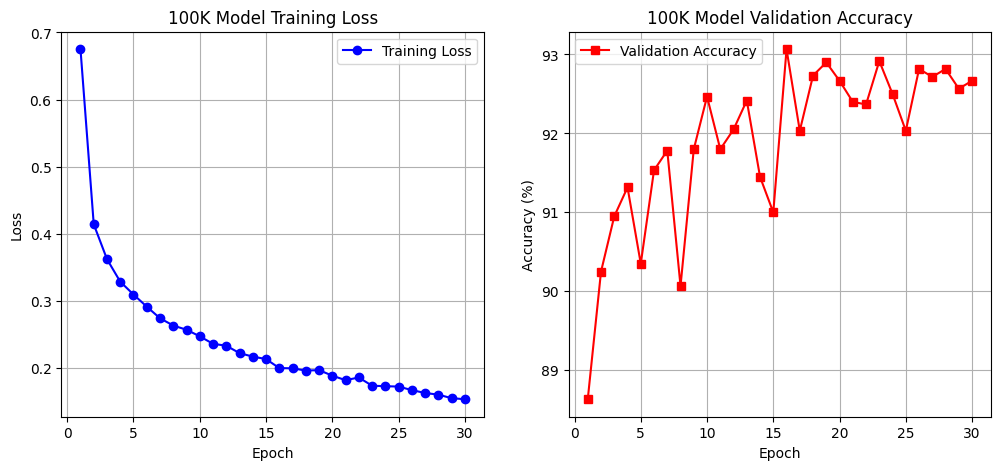

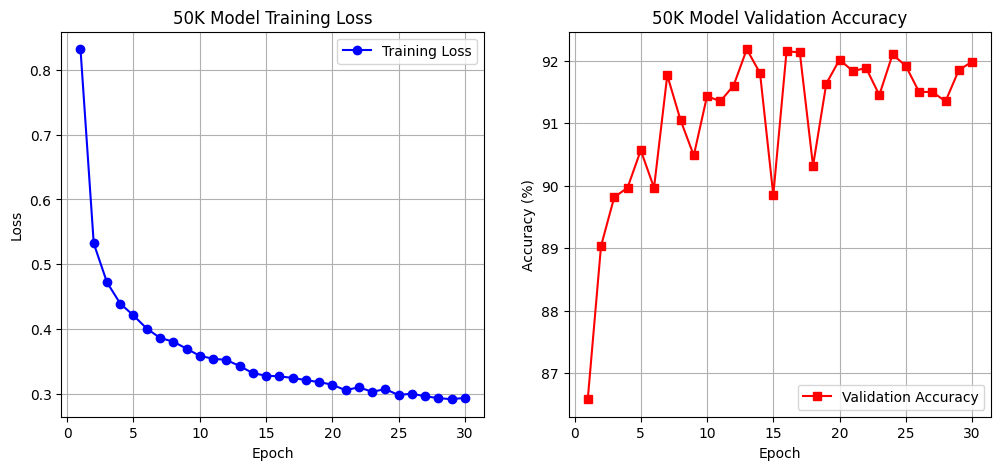

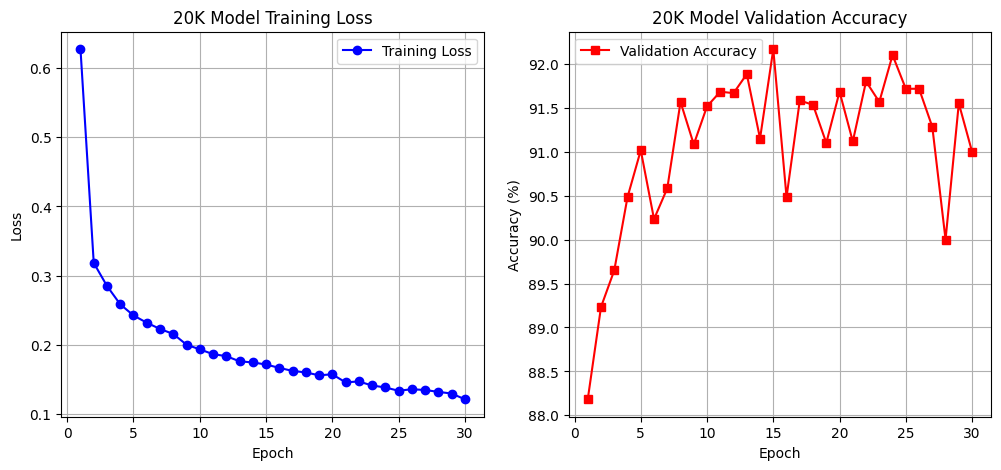

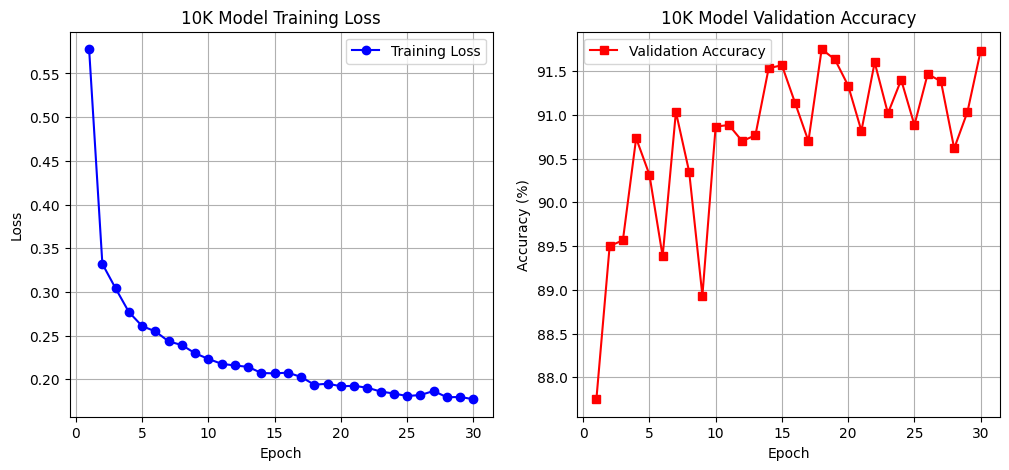

In [42]:
configs_CNN = ['100K', '50K', '20K', '10K']
results_CNN = {}
for config in configs_CNN:
    start_time = time.perf_counter()
    print(f'\nTraining {config} model...')
    model = CNN(config=config)
    model.config = config
    
    params = count_parameters(model)
    print(f'{config} model parameters: {params/1e3:.1f}K')
    
    train_loss, val_acc = train_model(model, train_batches, val_batches)
    
    results_CNN[config] = {
        'params': params,
        'train_loss': train_loss,
        'val_acc': val_acc,
        'test_acc': test_model(model, test_batches)
    }
    end_time = time.perf_counter()
    elapsed_time = end_time - start_time
    print(f"training time: {elapsed_time:.6f} s")
    

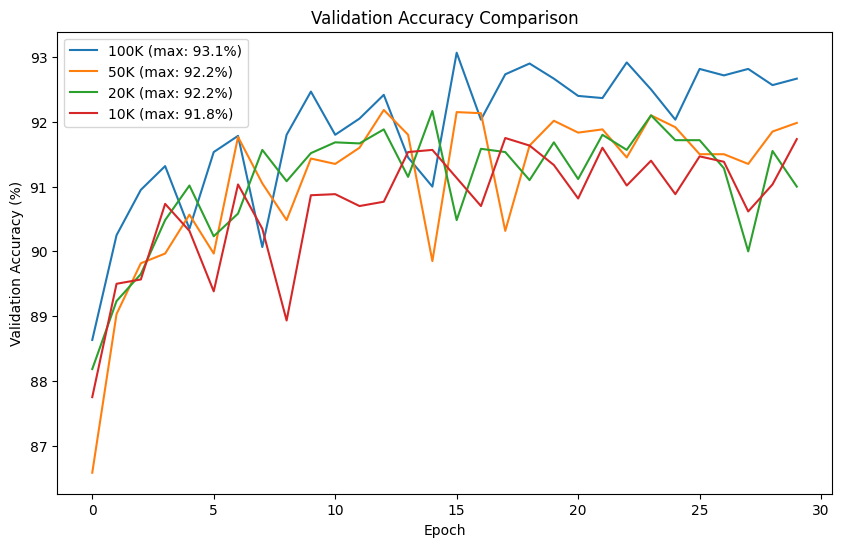

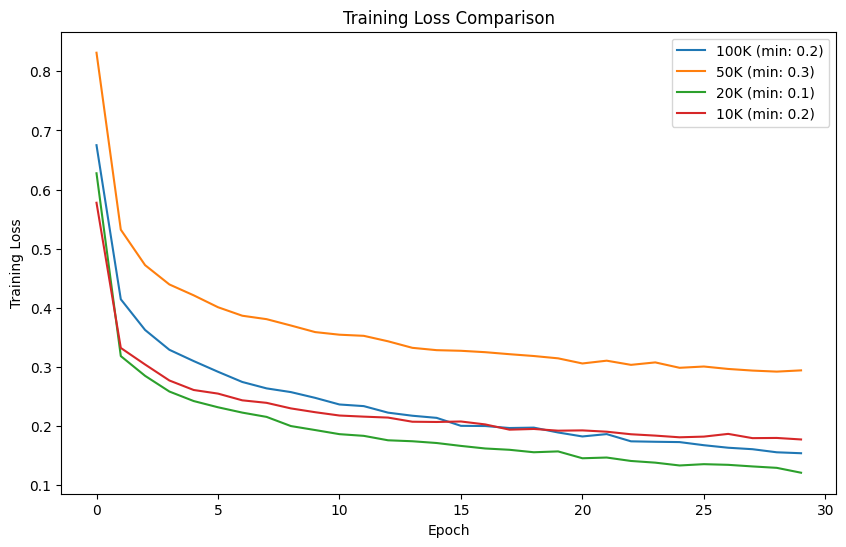

In [43]:
plt.figure(figsize=(10, 6))
for config in configs_CNN:
    plt.plot(results_CNN[config]['val_acc'], 
            label=f'{config} (max: {max(results_CNN[config]["val_acc"]):.1f}%)')
    plt.xlabel('Epoch')
    plt.ylabel('Validation Accuracy (%)')
    plt.title('Validation Accuracy Comparison')
    plt.legend()
plt.figure(figsize=(10, 6))
for config in configs_CNN:   
    plt.plot(results_CNN[config]['train_loss'], 
            label=f'{config} (min: {min(results_CNN[config]["train_loss"]):.1f})')
    plt.xlabel('Epoch')
    plt.ylabel('Training Loss')
    plt.title('Training Loss Comparison')
    plt.legend()

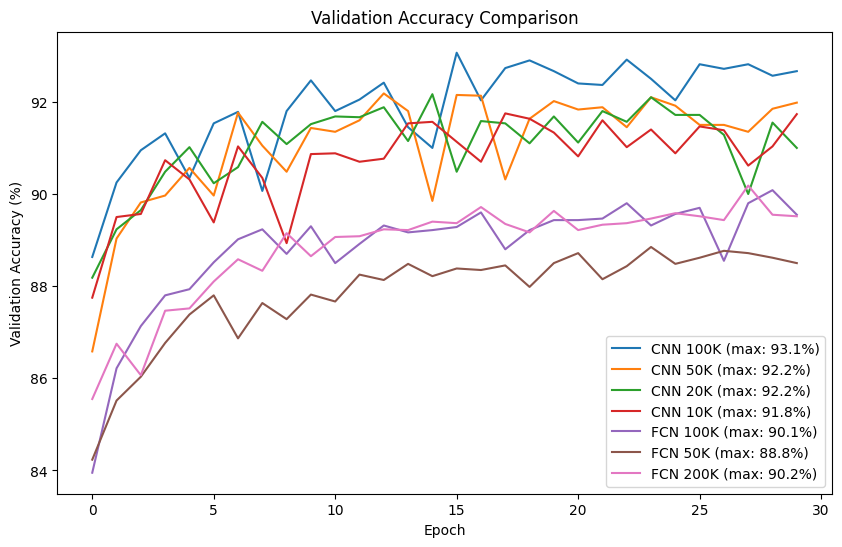

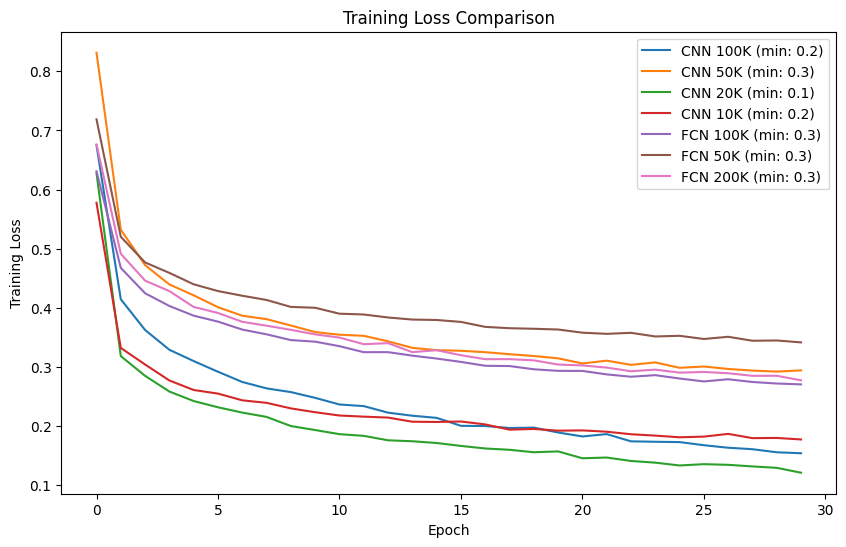

In [44]:
plt.figure(figsize=(10, 6))
for config in configs_CNN:
    plt.plot(results_CNN[config]['val_acc'], 
            label=f'CNN {config} (max: {max(results_CNN[config]["val_acc"]):.1f}%)')
    plt.xlabel('Epoch')
    plt.ylabel('Validation Accuracy (%)')
    plt.title('Validation Accuracy Comparison')
for config in configs_FCN:
    plt.plot(results_FCN[config]['val_acc'], 
            label=f'FCN {config} (max: {max(results_FCN[config]["val_acc"]):.1f}%)')
    plt.xlabel('Epoch')
    plt.ylabel('Validation Accuracy (%)')
    plt.title('Validation Accuracy Comparison')
    plt.legend()

plt.figure(figsize=(10, 6))
for config in configs_CNN:   
    plt.plot(results_CNN[config]['train_loss'], 
            label=f'CNN {config} (min: {min(results_CNN[config]["train_loss"]):.1f})')
    plt.xlabel('Epoch')
    plt.ylabel('Training Loss')
    plt.title('Training Loss Comparison')
for config in configs_FCN:
    plt.plot(results_FCN[config]['train_loss'], 
            label=f'FCN {config} (min: {min(results_FCN[config]["train_loss"]):.1f})')
    plt.xlabel('Epoch')
    plt.ylabel('Training Loss')
    plt.title('Training Loss Comparison')
    plt.legend()